In [40]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from numba import njit

G = 6.6743e-11
M_SUN = 1.988416e30
M_EARTH = 5.97217e24
AU = 1.495978707e11
YR = np.sqrt(4 * np.pi**2 * AU**3 / (G * (M_EARTH + M_SUN)))

## Solver

In [41]:
@njit
def f(y, m):
    """
    JITted derivative function for the n-body problem.

    Parameters:
    * y: phase space vector (np.ndarray of shape (2n, D))
    * m: masses of the bodies (np.ndarray of shape (n,))

    Returns:
    * dy: derivative of phase space vector (np.ndarray of shape (2n, D))
    """
    dy = np.zeros_like(y)
    n = y.shape[0] // 2
    dy[:n] = y[n:]
    x = y[:n]
    for i in range(n):
        for j in range(n):
            if j == i:
                continue
            dy[n + i] += G * m[j] * (x[j] - x[i]) / np.linalg.norm(x[j] - x[i])**3
    return dy

@njit
def RK4(x0, m, t0, tf, N):
    """
    JITted RK4 kernel for the n-body problem.
    
    Parameters:
    * x0: initial phase space vector (np.ndarray of shape (2n, D))
    * m: masses of the bodies (np.ndarray of shape (n,))
    * t0: initial time (float)
    * tf: final time (float)
    * N: number of time steps (int)

    Returns:
    * x: phase space vector at each time step (np.ndarray of shape (N + 1, 2n, D))
    """
    t = np.linspace(t0, tf, N + 1)
    x = np.zeros((N + 1, x0.shape[0], x0.shape[1]))
    h = (tf - t0) / N
    x[0] = x0
    for i in range(N):
        k1 = f(x[i], m)
        k2 = f(x[i] + h * k1 / 2, m)
        k3 = f(x[i] + h * k2 / 2, m)
        k4 = f(x[i] + h * k3, m)
        x[i + 1] = x[i] + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    return x

In [42]:
def n_body(m, x0, v0, tf, N):
    """
    N-body integrator using RK4. Wrapper for RK4_fast.
    
    m: masses (np.ndarray of shape (n,))
    x0: initial positions (np.ndarray of shape (n, D))
    v0: initial velocities (np.ndarray of shape (n, D))
    tf: final time (float)
    N: number of time steps (int)
    Returns: phase space vector (np.ndarray of shape (N + 1, 2n, D))
    """

    return RK4(np.concatenate((x0, v0), axis = 0), m, 0, tf, N)

## Results
### Equal Masses

In [43]:
r = AU
m = np.array([M_SUN, M_SUN])
x0 = np.array([[r / 2, 0], [-r / 2, 0]])
v0 = np.array([[0, np.sqrt(G * m[1]**2 / ((m[0] + m[1]) * r))], [0, -np.sqrt(G * m[0]**2 / ((m[0] + m[1]) * r))]])
tf = 2 * np.sqrt(4 * np.pi**2 * r**3 / (G * (m[0] + m[1])))
N = 10000
sol = n_body(m, x0, v0, tf, N)
sol_x = sol[:, :len(m), :]
sol_v = sol[:, len(m):, :]
t = np.linspace(0, tf, N + 1)

r0 = np.average(x0, axis = 0, weights = m)
r_sim = np.linalg.norm(sol_x - r0[np.newaxis, np.newaxis, :], axis = 2)

r_final = r_sim[-1]
r_exp = r * m[::-1] / np.sum(m)
r_err = np.abs(r_final - r_exp) / r_exp
print("Final orbital radii: ", r_final)
print("Expected orbital radii: ", r_exp)
print("Relative error: ", r_err)

Final orbital radii:  [7.47989354e+10 7.47989354e+10]
Expected orbital radii:  [7.47989354e+10 7.47989354e+10]
Relative error:  [3.67195338e-15 3.67195338e-15]


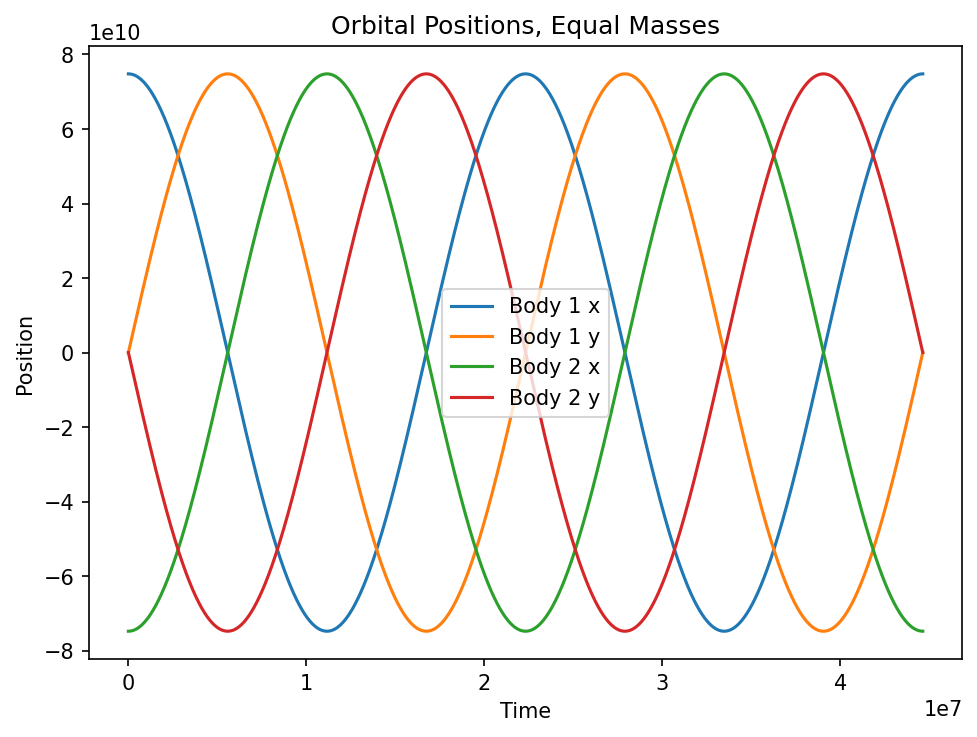

In [44]:
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
plt.plot(t, sol_x[:, 0, 0], label = "Body 1 x")
plt.plot(t, sol_x[:, 0, 1], label = "Body 1 y")
plt.plot(t, sol_x[:, 1, 0], label = "Body 2 x")
plt.plot(t, sol_x[:, 1, 1], label = "Body 2 y")
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Orbital Positions, Equal Masses")
plt.legend()

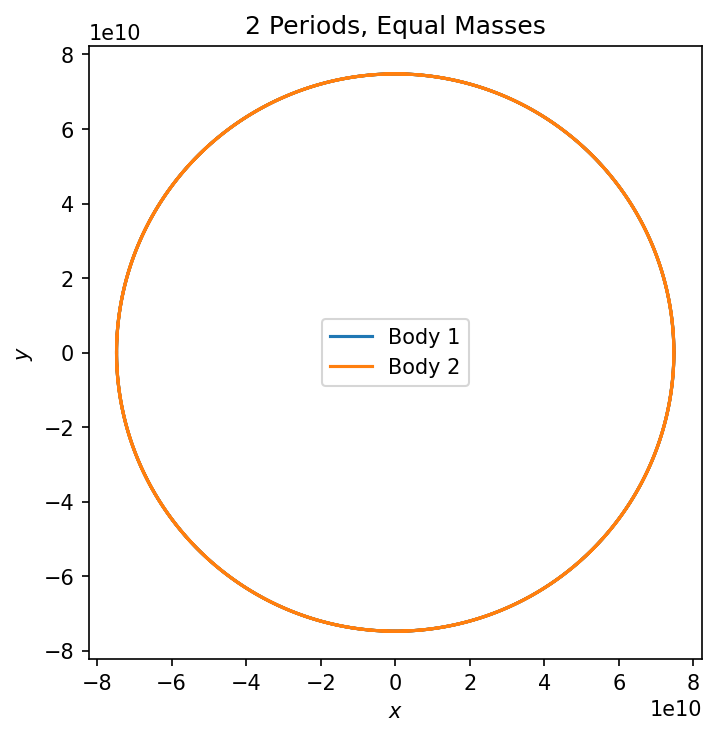

In [45]:
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
ax.set_aspect("equal")
plt.plot(sol_x[:, 0, 0], sol_x[:, 0, 1], label = "Body 1")
plt.plot(sol_x[:, 1, 0], sol_x[:, 1, 1], label = "Body 2")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("2 Periods, Equal Masses")
plt.legend()

### Unequal Masses

In [46]:
r = AU
m = np.array([M_EARTH, M_SUN])
x0 = np.array([[r / 2, 0], [-r / 2, 0]])
v0 = np.array([[0, np.sqrt(G * m[1]**2 / ((m[0] + m[1]) * r))], [0, -np.sqrt(G * m[0]**2 / ((m[0] + m[1]) * r))]])
tf = 2 * np.sqrt(4 * np.pi**2 * r**3 / (G * (m[0] + m[1])))
N = 10000
sol = n_body(m, x0, v0, tf, N)
sol_x = sol[:, :len(m), :]
sol_v = sol[:, len(m):, :]
t = np.linspace(0, tf, N + 1)

r0 = np.average(x0, axis = 0, weights = m)
r_sim = np.linalg.norm(sol_x - r0[np.newaxis, np.newaxis, :], axis = 2)

r_final = r_sim[-1]
r_exp = r * m[::-1] / np.sum(m)
r_err = np.abs(r_final - r_exp) / r_exp
print("Final orbital radii: ", r_final)
print("Expected orbital radii: ", r_exp)
print("Relative error: ", r_err)

Final orbital radii:  [1.49597421e+11 4.49313037e+05]
Expected orbital radii:  [1.49597421e+11 4.49313037e+05]
Relative error:  [1.10158932e-14 3.71556974e-12]


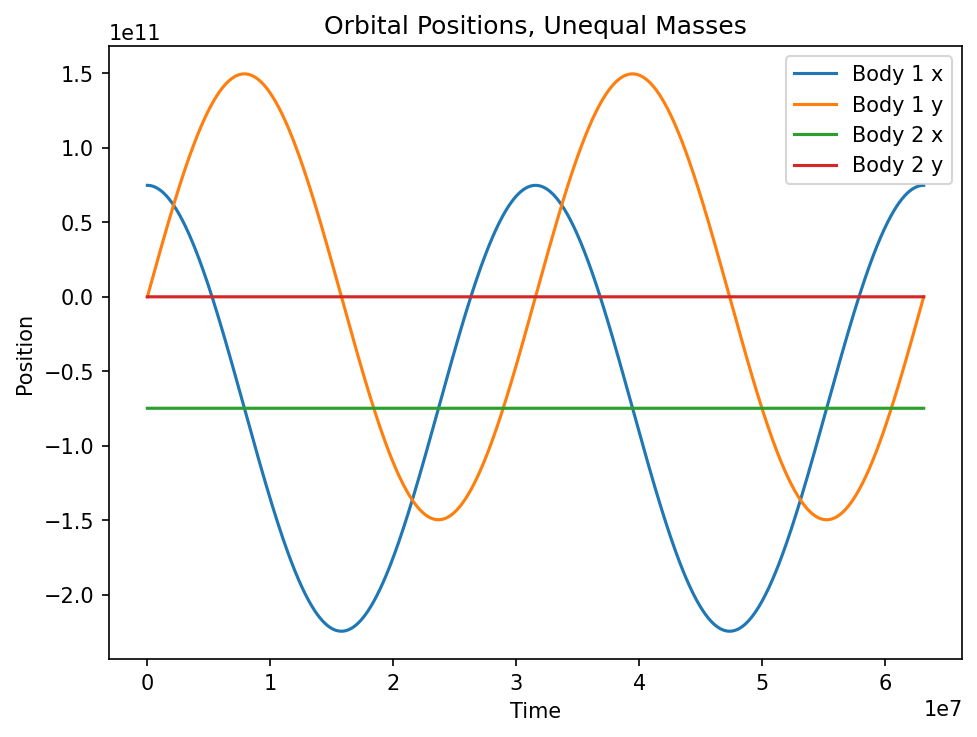

In [47]:
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
plt.plot(t, sol_x[:, 0, 0], label = "Body 1 x")
plt.plot(t, sol_x[:, 0, 1], label = "Body 1 y")
plt.plot(t, sol_x[:, 1, 0], label = "Body 2 x")
plt.plot(t, sol_x[:, 1, 1], label = "Body 2 y")
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Orbital Positions, Unequal Masses")
plt.legend()

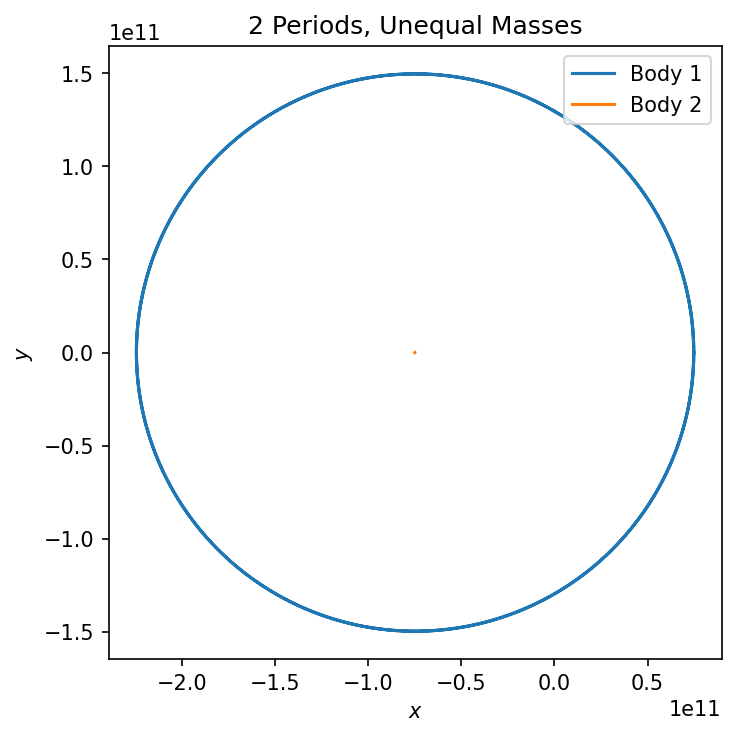

In [48]:
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
ax.set_aspect("equal")
plt.plot(sol_x[:, 0, 0], sol_x[:, 0, 1], label = "Body 1")
plt.plot(sol_x[:, 1, 0], sol_x[:, 1, 1], label = "Body 2")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("2 Periods, Unequal Masses")
plt.legend()

### Convergence diagnostics

In [53]:
orbits = 1000

r = AU
m = np.array([M_SUN, M_SUN])
x0 = np.array([[r / 2, 0], [-r / 2, 0]])
v0 = np.array([[0, np.sqrt(G * m[1]**2 / ((m[0] + m[1]) * r))], [0, -np.sqrt(G * m[0]**2 / ((m[0] + m[1]) * r))]])
tf = orbits * np.sqrt(4 * np.pi**2 * r**3 / (G * (m[0] + m[1])))
N = orbits * 1000
sol = n_body(m, x0, v0, tf, N)
sol_x = sol[:, :len(m), :]
sol_v = sol[:, len(m):, :]
t = np.linspace(0, tf, N + 1)

r0 = np.average(x0, axis = 0, weights = m)
r_sim = np.linalg.norm(sol_x - r0[np.newaxis, np.newaxis, :], axis = 2)

r_final = r_sim[-1]
r_exp = r * m[::-1] / np.sum(m)
r_err = np.abs(r_final - r_exp) / r_exp
print("Final orbital radii: ", r_final)
print("Expected orbital radii: ", r_exp)
print("Relative error: ", r_err)

Final orbital radii:  [7.47989352e+10 7.47989352e+10]
Expected orbital radii:  [7.47989354e+10 7.47989354e+10]
Relative error:  [1.70920168e-09 1.70920168e-09]


Text(0.5, 1.0, '1000 Orbits, Equal Masses')

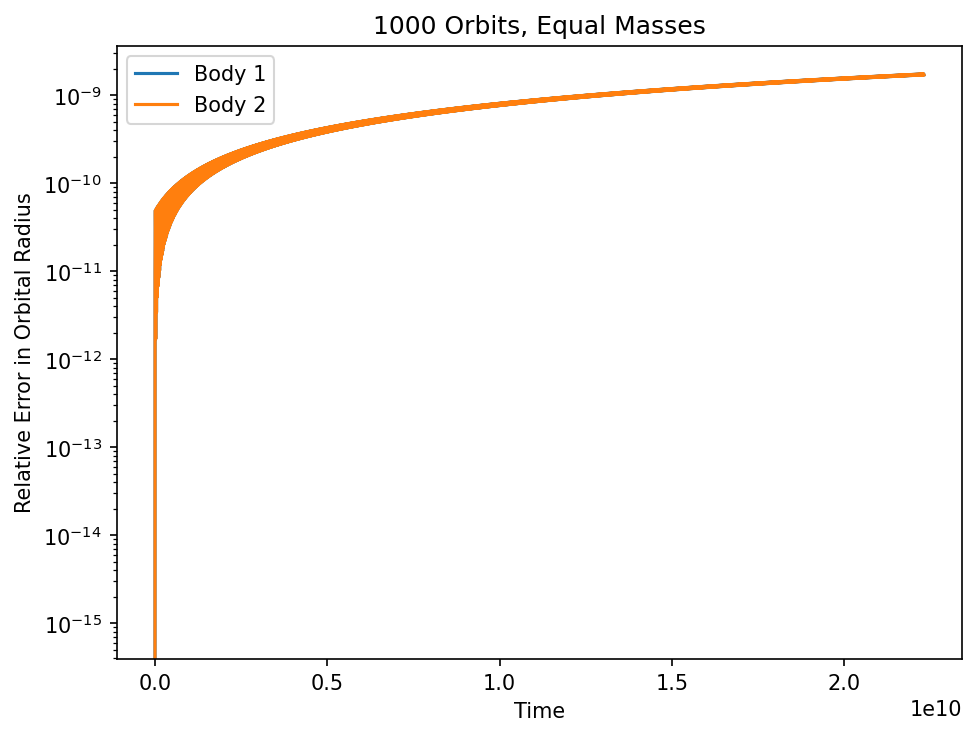

In [54]:
r_errs = np.abs(r_sim - r_exp) / r_exp
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
plt.plot(t, r_errs[:,0], label = "Body 1")
plt.plot(t, r_errs[:,1], label = "Body 2")
plt.xlabel("Time")
plt.ylabel("Relative Error in Orbital Radius")
plt.yscale("log")
plt.legend()
plt.title(f"{orbits} Orbits, Equal Masses")

In [55]:
orbits = 1000

r = AU
m = np.array([M_EARTH, M_SUN])
x0 = np.array([[r / 2, 0], [-r / 2, 0]])
v0 = np.array([[0, np.sqrt(G * m[1]**2 / ((m[0] + m[1]) * r))], [0, -np.sqrt(G * m[0]**2 / ((m[0] + m[1]) * r))]])
tf = orbits * np.sqrt(4 * np.pi**2 * r**3 / (G * (m[0] + m[1])))
N = orbits * 1000
sol = n_body(m, x0, v0, tf, N)
sol_x = sol[:, :len(m), :]
sol_v = sol[:, len(m):, :]
t = np.linspace(0, tf, N + 1)

r0 = np.average(x0, axis = 0, weights = m)
r_sim = np.linalg.norm(sol_x - r0[np.newaxis, np.newaxis, :], axis = 2)

r_final = r_sim[-1]
r_exp = r * m[::-1] / np.sum(m)
r_err = np.abs(r_final - r_exp) / r_exp
print("Final orbital radii: ", r_final)
print("Expected orbital radii: ", r_exp)
print("Relative error: ", r_err)

Final orbital radii:  [1.49597421e+11 4.49313038e+05]
Expected orbital radii:  [1.49597421e+11 4.49313037e+05]
Relative error:  [1.70913603e-09 1.93976227e-09]


Text(0.5, 1.0, '1000 Orbits, Unequal Masses')

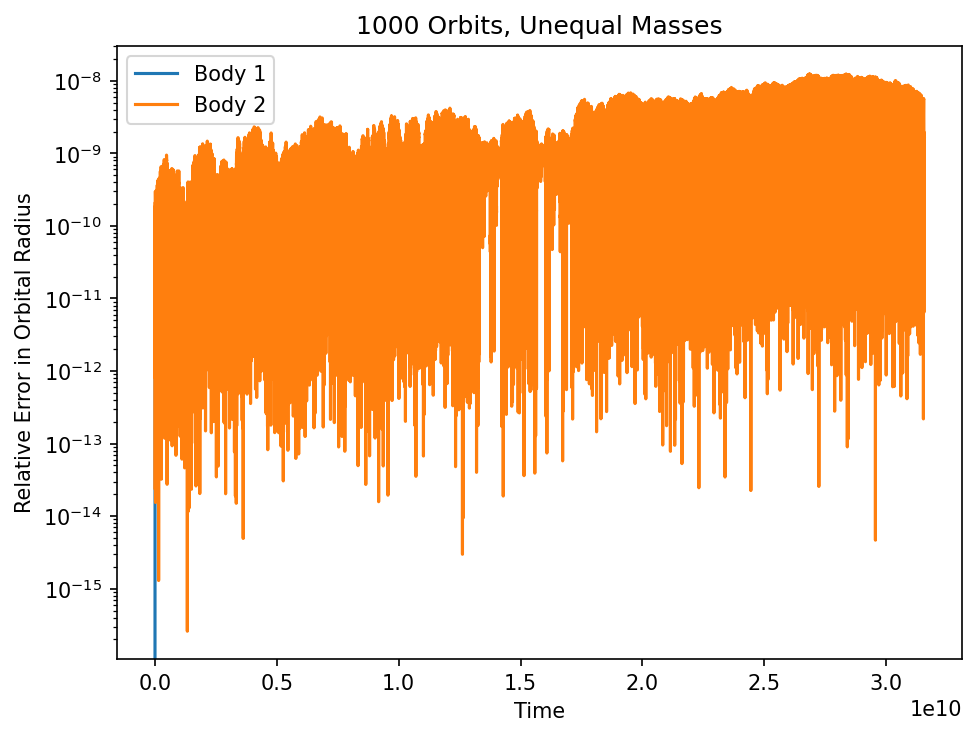

In [56]:
r_errs = np.abs(r_sim - r_exp) / r_exp
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
plt.plot(t, r_errs[:,0], label = "Body 1")
plt.plot(t, r_errs[:,1], label = "Body 2")
plt.xlabel("Time")
plt.ylabel("Relative Error in Orbital Radius")
plt.yscale("log")
plt.legend()
plt.title(f"{orbits} Orbits, Unequal Masses")

### Fun

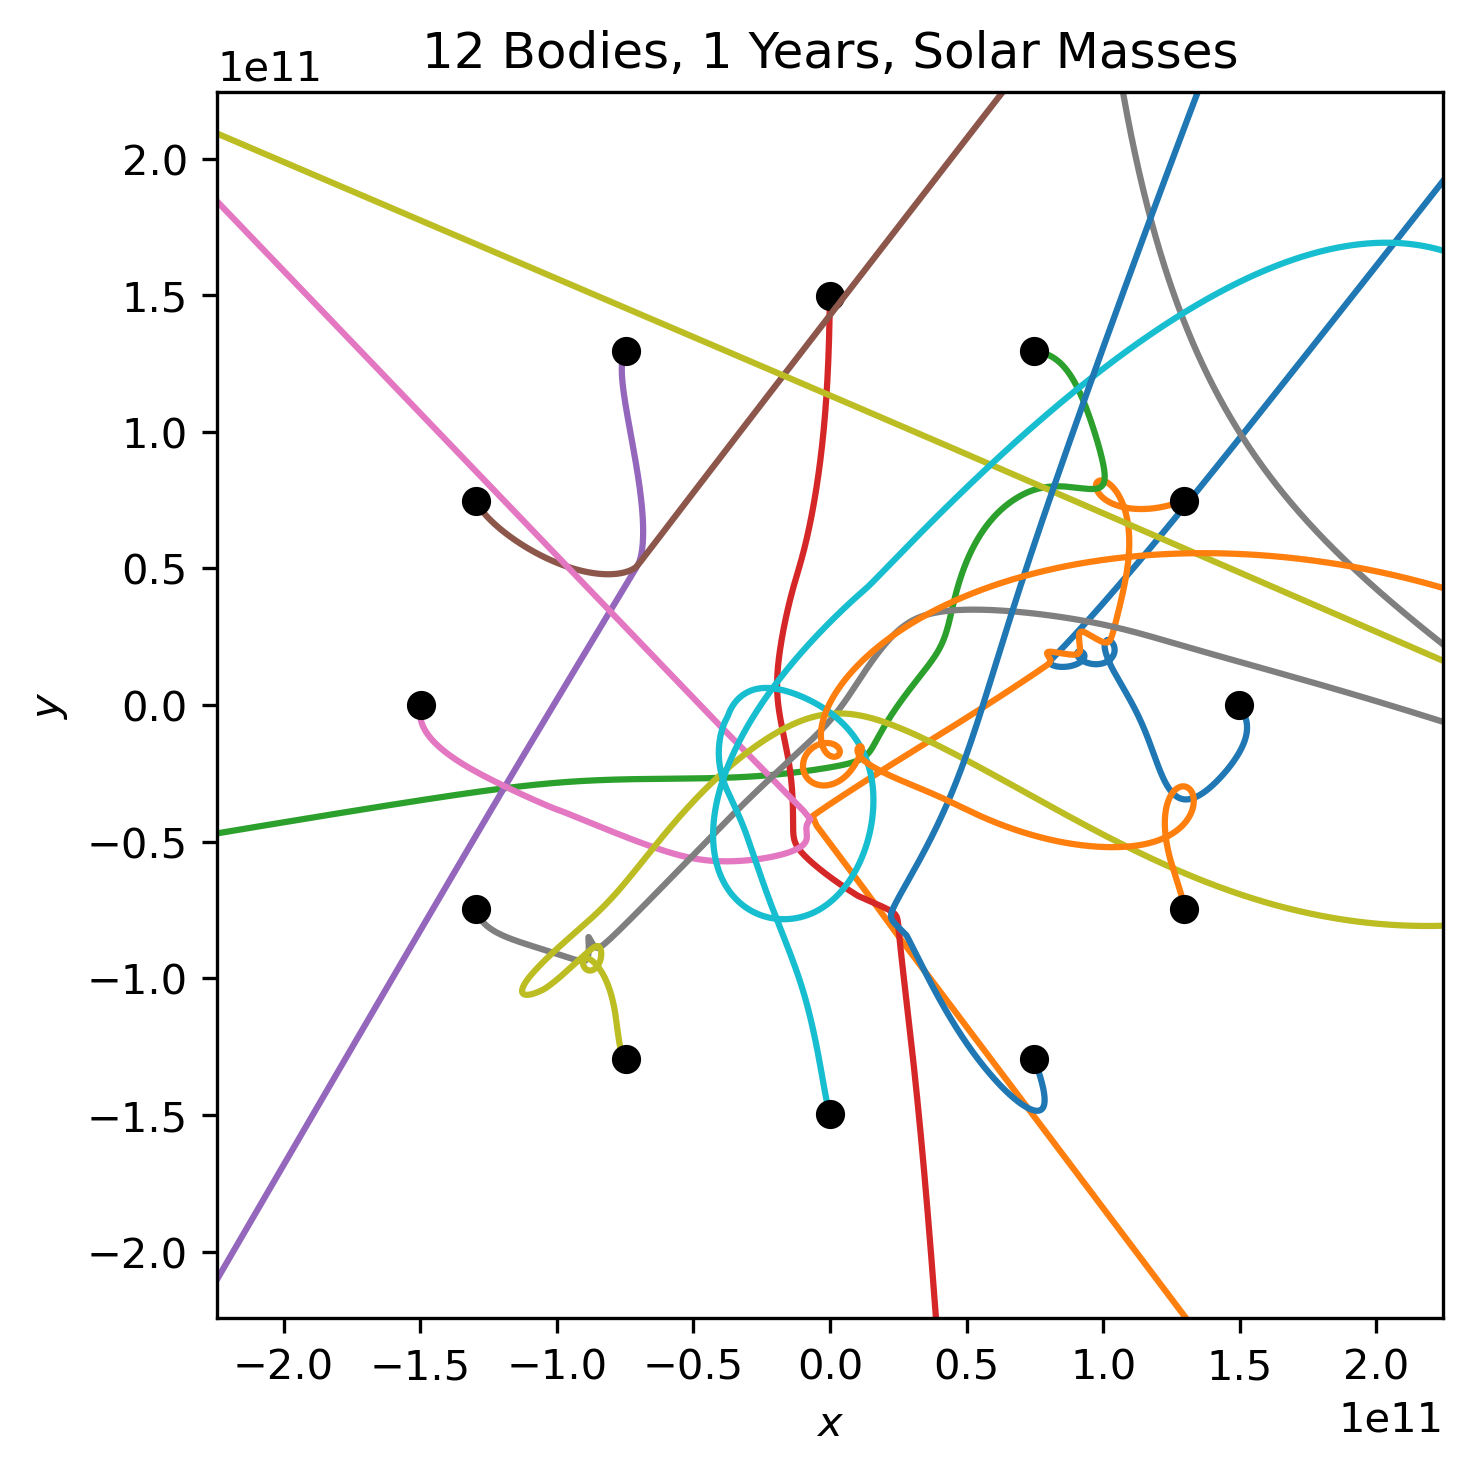

In [67]:
n_bodies = 12
yrs = 1
v_scale = 0.5 # Random velocity scale

m = M_SUN * np.ones(n_bodies)
angles = np.linspace(0, 2 * np.pi, n_bodies, endpoint = False)

x0 = AU * np.stack([np.cos(angles), np.sin(angles)], axis = 1)
v0 = 2 * np.pi * AU / YR * np.random.normal(size = (n_bodies, 2)) * v_scale
tf = YR * yrs
N = 10000 * yrs
sol = n_body(m, x0, v0, tf, int(N))
sol_x = sol[:, :len(m), :]
sol_v = sol[:, len(m):, :]
t = np.linspace(0, tf, int(N) + 1)

fig, ax = plt.subplots(dpi = 300, layout = "constrained")
ax.set_aspect("equal")
for i in range(n_bodies):
    plt.plot(sol_x[:, i, 0], sol_x[:, i, 1], label = f"Body {i + 1}")
    plt.plot(x0[i, 0], x0[i, 1], 'o', color = 'black')
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.xlim(-1.5 * AU, 1.5 * AU)
plt.ylim(-1.5 * AU, 1.5 * AU)
plt.title(f"{n_bodies} Bodies, {yrs} Years, Solar Masses")
# plt.legend()
plt.savefig(f"{n_bodies}_bodies.png")